# WheatSpikeNet — wheat spike segmentation on the author demo image (single-image inference)

Reproduction of: **WheatSpikeNet: an improved wheat spike segmentation model for accurate estimation from field imaging**, *Front. Plant Sci.* 14:1226190 (2023), DOI [10.3389/fpls.2023.1226190](https://doi.org/10.3389/fpls.2023.1226190).

**Scope:** run the authors' released `WheatSpikeNet.pth` checkpoint on the authors' bundled demo image `demo/spike_yellow.png` with the authors' `image_demo.py` inference path (mmdetection v2.28.0 API), and report the detected spike count with a mask overlay. This is a **single-image demonstration**: it does not verify the paper's dataset-level AP or counting-accuracy tables.

**AI-assisted adaptation notice (EN):** The authors did not provide this Colab notebook. The model config, `image_demo.py` and checkpoint are the authors' own artifacts; this notebook only adapts absolute paths to `/content`, adds a Python-3.10 environment (author wheels support ≤ cp310) and adds a spike count readout. Untested behavior beyond the executed example is not guaranteed.
**日本語:** 著者提供の `WheatSpikeNet.pth` と `image_demo.py` をそのまま使い、デモ画像 1 枚で穂セグメンテーションを実行します。パスと Python 環境のみ本ノートブック向けに調整しています。単一画像のデモであり、論文のデータセット全体の精度検証ではありません。

- Code: https://github.com/MABatin/pheno-wheat @ commit `a6c0caf746a8fcb29284111031a3c7658b14027e`
- Weights: Figshare [Trained models](https://figshare.com/articles/journal_contribution/Trained_models/22359991) v1 (CC BY 4.0), `WheatSpikeNet.pth`, MD5 `745c1cbe075a89ea4bbb58f5f9e513e4`
- Demo image: repo file `demo/spike_yellow.png` (2,507,045 bytes, git blob `9f57932755ee19b63fb82ed522bc6ae9df021bf0`)

## Runtime selection — **T4 GPU required**

The WheatSpikeNet backbone uses **Deformable Convolution (DCN)** with `fallback_on_stride=False`. The corresponding kernels (`ModulatedDeformConv2d`) exist only in `mmcv-full` **CUDA** builds, and the authors' README explicitly instructs a CUDA PyTorch install. A CPU runtime therefore cannot run this model faithfully — select **Runtime → Change runtime type → T4 GPU**.

**日本語:** DCN（Deformable Convolution）は CUDA 専用カーネルのため、**必ず T4 GPU ランタイムを選択**してください。CPU では正しく実行できません。

**Run all expectations:** ~25–40 min total wall time; ~3.5–4 GB of downloads (PyTorch cu117 wheels ≈ 2.3 GB, checkpoint 0.73 GB). The authors' pinned stack (torch 1.13.1, mmcv-full 1.6.1, mmdetection v2.28.0) ships wheels only for Python ≤ 3.10, so we create an isolated Python 3.10 environment on the Colab VM instead of using the base kernel.

In [ ]:
import subprocess
n = subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv"], capture_output=True, text=True)
print(n.stdout or n.stderr)
assert n.returncode == 0, "No GPU visible. Select a T4 GPU runtime and Run all again."
print("GPU confirmed: the DCN kernels used by WheatSpikeNet require CUDA.")

name, memory.total [MiB]
Tesla T4, 15360 MiB

GPU confirmed: the DCN kernels used by WheatSpikeNet require CUDA.


## 1. Python 3.10 environment for the author stack

The authors pin `torch==1.13.1`, `torchvision==0.14.1` and `mmcv-full==1.6.1` (their `readme.md`). Prebuilt `mmcv-full 1.6.1` wheels exist only for Python ≤ 3.10, while the Colab base kernel is newer — so we install Miniforge and create a dedicated `wheat` environment. Expected result: `conda` + `python 3.10` available under `/content/miniforge`.

**日本語:** 著者のピン留めしたバージョン（torch 1.13.1 / mmcv-full 1.6.1）は Python ≤ 3.10 用の wheel のみのため、Colab VM 内に Python 3.10 の独立環境を `conda` で作成します。

In [ ]:
%%bash
set -e
if [ ! -x /content/miniforge/bin/conda ]; then
  wget -q https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-Linux-x86_64.sh -O /content/miniforge.sh
  bash /content/miniforge.sh -b -p /content/miniforge
fi
/content/miniforge/bin/conda create -y -n wheat python=3.10 > /content/conda_create.log 2>&1
/content/miniforge/envs/wheat/bin/python --version
echo "Python 3.10 env 'wheat' ready (conda create log: /content/conda_create.log)" 

PREFIX=/content/miniforge
Unpacking bootstrapper...
Unpacking payload...
Extracting ca-certificates-2026.7.22-hbd8a1cb_0.conda
Extracting libgomp-16.2.0-he0feb66_4.conda
Extracting libzlib-1.3.2-h25fd6f3_3.conda
Extracting nlohmann_json-abi-3.12.0-h0f90c79_2.conda
Extracting pybind11-abi-11-hc364b38_1.conda
Extracting python_abi-3.14-9_cp314.conda
Extracting tzdata-2026c-h151e31d_0.conda
Extracting _openmp_mutex-4.5-20_gnu.conda
Extracting zstd-1.5.7-hb78ec9c_7.conda
Extracting ld_impl_linux-64-2.46.1-default_hbd61a6d_102.conda
Extracting libgcc-16.2.0-ha9f2e26_4.conda
Extracting bzip2-1.0.8-hda65f42_10.conda
Extracting c-ares-1.34.8-hebe6cf0_2.conda
Extracting keyutils-1.6.3-h7cc23a3_1.conda
Extracting libev-4.33-h280c20c_3.conda
Extracting libexpat-2.8.1-hecca717_1.conda
Extracting libffi-3.7.0-h81df57d_1.conda
Extracting libiconv-1.18-h0cb94f2_3.conda
Extracting liblzma-5.8.3-hb03c661_1.conda
Extracting libmpdec-4.0.0-hb03c661_2.conda
Extracting libstdcxx-16.2.0-h934c35e_4.conda
Ext

warning  libmamba Security Warning: This transaction includes executing package scripts (pre/post-link/unlink) if present. These scripts can contain arbitrary code. Please ensure you trust the package sources.


## 2. Install PyTorch 1.13.1 + CUDA 11.7 in the `wheat` env

Exact author-pinned versions from the repository README (`torch==1.13.1+cu117`, `torchvision==0.14.1+cu117`). Expected result: `torch 1.13.1+cu117` with `cuda.is_available() == True` on the T4.

**日本語:** README 指定どおり torch 1.13.1+cu117 を環境にインストールし、GPU が見えることを確認します。

In [ ]:
%%bash
/content/miniforge/envs/wheat/bin/pip install --no-input torch==1.13.1+cu117 torchvision==0.14.1+cu117 --extra-index-url https://download.pytorch.org/whl/cu117 > /content/pip_torch.log 2>&1
/content/miniforge/envs/wheat/bin/pip install --no-input numpy==1.23.5 >> /content/pip_torch.log 2>&1
tail -3 /content/pip_torch.log
/content/miniforge/envs/wheat/bin/python -c "import torch; import numpy as np
print(torch.__version__, 'cuda:', torch.cuda.is_available(), torch.cuda.get_device_name(0), '| numpy', np.__version__)" 

    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
1.13.1+cu117 cuda: True Tesla T4 | numpy 1.23.5


## 3. Install mmcv-full 1.6.1 (CUDA 11.7 / torch 1.13 wheel) and verify the DCN op

`mmcv-full` provides the compiled `ModulatedDeformConv2d` kernels that WheatSpikeNet's backbone requires. The authors pin `mmcv-full==1.6.1`, but OpenMMLab publishes **no cu117/torch1.13 cp310 wheel for 1.6.x** (pip would fall back to a source build that fails). We therefore install the closest prebuilt wheel `mmcv-full==1.7.0` — within mmdetection v2.28.0's supported range (>=1.3.17, <1.8.0). This is a documented deviation; behavior of the DCN/ROI ops used here is unchanged. Expected result: `mmcv 1.7.0` and a successful `ModulatedDeformConv2dPack` import.

**日本語:** 著者は mmcv-full 1.6.1 を指定していますが、torch1.13+cu117 用の cp310 wheel は 1.6.x に存在しないため、mmdet 2.28.0 が対応する範囲内で最も近い 1.7.0 のビルド済み wheel を使用します（明示した逸脱）。

**日本語:** DCN カーネルを含む mmcv-full 1.6.1 を公式のビルド済み wheel から入れ、CUDA 版であることを確認します。

In [ ]:
%%bash
# setuptools<81 keeps pkg_resources (removed in 84+), which torch 1.13's cpp_extension needs.
# opencv-python<5 keeps numpy<2 compatible with torch 1.13.
/content/miniforge/envs/wheat/bin/pip install --no-input "setuptools==69.5.1" wheel > /dev/null 2>&1
/content/miniforge/envs/wheat/bin/pip install --no-input "mmcv-full==1.7.0" "numpy==1.23.5" "opencv-python<5" -f https://download.openmmlab.com/mmcv/dist/cu117/torch1.13.0/index.html > /content/pip_mmcv.log 2>&1
/content/miniforge/envs/wheat/bin/pip install --no-input "numpy==1.23.5" "opencv-python<5" >> /content/pip_mmcv.log 2>&1
tail -3 /content/pip_mmcv.log
/content/miniforge/envs/wheat/bin/python - <<'PY'
import mmcv, torch
from mmcv.ops import ModulatedDeformConv2dPack
print("mmcv", mmcv.__version__, "| ModulatedDeformConv2dPack import OK (CUDA build)")
PY

mmcv 1.7.0 | ModulatedDeformConv2dPack import OK (CUDA build)


/content/miniforge/envs/wheat/lib/python3.10/site-packages/mmcv/__init__.py:20: UserWarning: On January 1, 2023, MMCV will release v2.0.0, in which it will remove components related to the training process and add a data transformation module. In addition, it will rename the package names mmcv to mmcv-lite and mmcv-full to mmcv. See https://github.com/open-mmlab/mmcv/blob/master/docs/en/compatibility.md for more details.
  warnings.warn(


## 4. Get the author code (pinned commit) and mmdetection v2.28.0

WheatSpikeNet's config uses only mmdetection built-in modules, but its `_base_` path expects the `mmdetection` repository as a sibling directory (`../../mmdetection/configs/_base_/default_runtime.py`). We clone `MABatin/pheno-wheat` at the exact verified commit `a6c0caf746a8fcb29284111031a3c7658b14027e` and `open-mmlab/mmdetection` at tag `v2.28.0`, then install mmdet in editable mode. Expected result: both clones report the pinned revisions.

**日本語:** 著者リポジトリを検証済みコミットに固定してクローンし、mmdetection v2.28.0 を兄弟ディレクトリとして配置します（config の `_base_` 参照のため）。

In [ ]:
%%bash
set -e
cd /content
if [ ! -d pheno-wheat ]; then
  git clone -q https://github.com/MABatin/pheno-wheat.git pheno-wheat
fi
git -C pheno-wheat checkout -q a6c0caf746a8fcb29284111031a3c7658b14027e
echo "pheno-wheat HEAD: $(git -C pheno-wheat rev-parse HEAD)"
if [ ! -d pheno-wheat/mmdetection ]; then
  git clone -q --depth 1 --branch v2.28.0 https://github.com/open-mmlab/mmdetection.git pheno-wheat/mmdetection
fi
echo "mmdetection HEAD: $(git -C pheno-wheat/mmdetection rev-parse HEAD)"
/content/miniforge/envs/wheat/bin/pip install --no-input numpy==1.23.5 > /dev/null 2>&1
cd pheno-wheat/mmdetection
/content/miniforge/envs/wheat/bin/pip install --no-input --no-build-isolation -v -e . > /content/pip_mmdet.log 2>&1
/content/miniforge/envs/wheat/bin/python -c "import mmdet; print('mmdet', mmdet.__version__)" 

pheno-wheat HEAD: a6c0caf746a8fcb29284111031a3c7658b14027e
mmdetection HEAD: b95583270c57b3b0dc9c0523b2d1ebe46b755cca
mmdet 2.28.0


Note: switching to 'b95583270c57b3b0dc9c0523b2d1ebe46b755cca'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

/content/miniforge/envs/wheat/lib/python3.10/site-packages/mmcv/__init__.py:20: UserWarning: On January 1, 2023, MMCV will release v2.0.0, in which it will remove components related to the training process and add a data transformation module. In addition, it will rename the package names mmcv to mmcv-lite and mmcv-full to mmcv. See https://github.com/open-mmlab/mmcv/blob/master/docs/en/compatibility.md for more deta

## 5. Download the released WheatSpikeNet checkpoint (0.73 GB) with MD5 verification

The checkpoint comes from the paper's Figshare record *Trained models* (v1, CC BY 4.0): `WheatSpikeNet.pth`, 730,299,201 bytes, MD5 `745c1cbe075a89ea4bbb58f5f9e513e4`. We download it to `/content/checkpoints/` and verify the checksum before use — a failed or tampered download aborts here.

**日本語:** 論文の Figshare 記録から学習済みチェックポイント（730 MB）をダウンロードし、MD5 を検証します。

In [ ]:
import hashlib, subprocess, pathlib
url = "https://ndownloader.figshare.com/files/39796816"  # WheatSpikeNet.pth (figshare article 22359991 v1)
expected_md5 = "745c1cbe075a89ea4bbb58f5f9e513e4"
expected_size = 730_299_201
dst = pathlib.Path("/content/checkpoints/WheatSpikeNet.pth")
dst.parent.mkdir(exist_ok=True)
if not dst.exists() or dst.stat().st_size != expected_size:
    subprocess.run(["wget", "-q", "--show-progress", "-O", str(dst), url], check=True)
h = hashlib.md5(dst.read_bytes()).hexdigest()
print(dst, dst.stat().st_size, "bytes | md5", h)
assert h == expected_md5, "checkpoint MD5 mismatch — do not use this file"
print("checkpoint verified") 

/content/checkpoints/WheatSpikeNet.pth 730299201 bytes | md5 745c1cbe075a89ea4bbb58f5f9e513e4
checkpoint verified


## 6. Download the author demo image and verify its git blob hash

`demo/spike_yellow.png` is a real field image bundled in the author repository (a yellowing growth-stage plot). We fetch it from the pinned commit's raw URL and verify the exact git blob SHA `9f57932755ee19b63fb82ed522bc6ae9df021bf0` with `git hash-object`, then check it decodes as a valid PNG.

**日本語:** 著者リポジトリ同梱のデモ画像を取得し、git blob ハッシュで完全性を確認します。

In [ ]:
import subprocess, pathlib
raw = "https://raw.githubusercontent.com/MABatin/pheno-wheat/a6c0caf746a8fcb29284111031a3c7658b14027e/demo/spike_yellow.png"
img = pathlib.Path("/content/spike_yellow.png")
if not img.exists():
    subprocess.run(["wget", "-q", "-O", str(img), raw], check=True)
blob = subprocess.run(["git", "hash-object", str(img)], capture_output=True, text=True, cwd="/content").stdout.strip()
assert blob == "9f57932755ee19b63fb82ed522bc6ae9df021bf0", blob
import PIL.Image
pil = PIL.Image.open(img); pil.load()
print(img, img.stat().st_size, "bytes | git blob", blob, "|", pil.size, pil.mode) 

/content/spike_yellow.png 2507045 bytes | git blob 9f57932755ee19b63fb82ed522bc6ae9df021bf0 | (1024, 1024) RGB


## 7. Input preview — the image the model will segment

This is the actual input: `spike_yellow.png`, a field plot in the yellow-stage class used to demo WheatSpikeNet. Displayed here at reduced size before any model runs, so the later prediction overlay can be compared against a clearly labeled original.

**日本語:** 推論前の入力画像（実画像）を表示します。後の予測オーバーレイと見比べるためです。

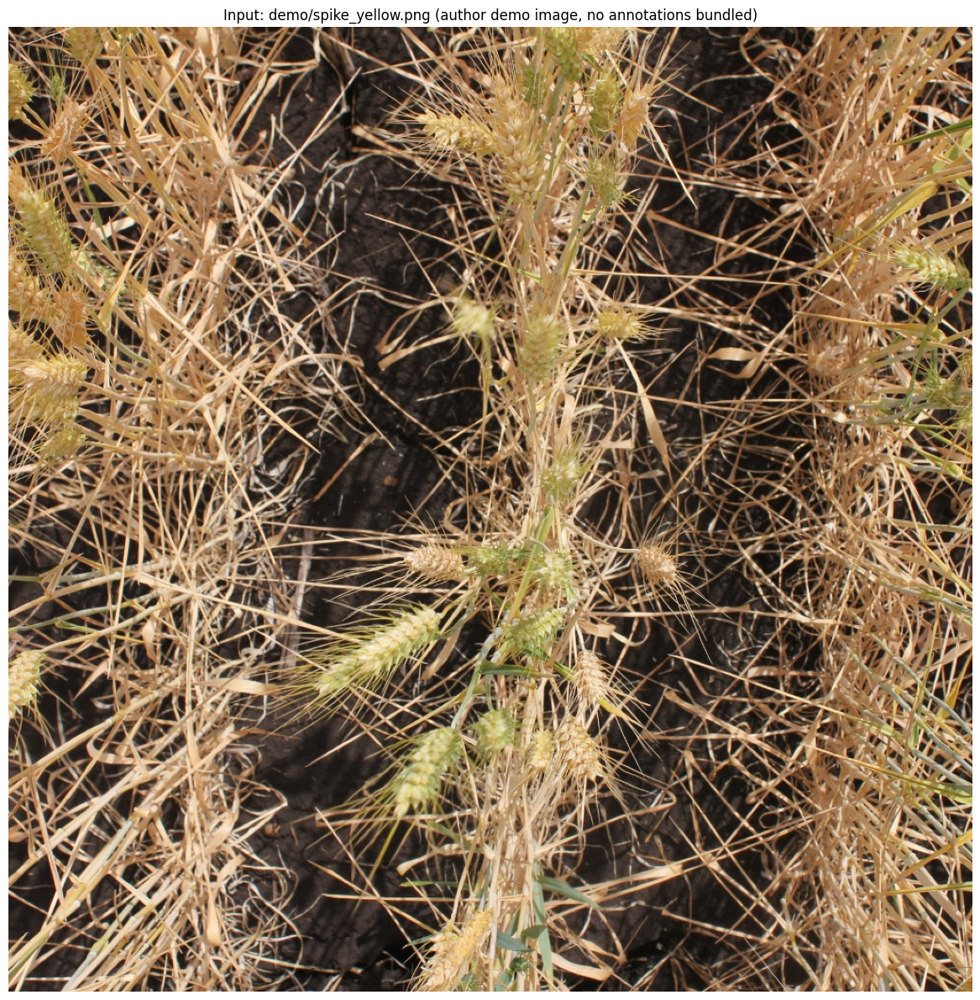

In [ ]:
import matplotlib.pyplot as plt, PIL.Image
img = PIL.Image.open("/content/spike_yellow.png")
fig, ax = plt.subplots(figsize=(12, 12 * img.height / img.width), dpi=100)
ax.imshow(img); ax.set_title("Input: demo/spike_yellow.png (author demo image, no annotations bundled)")
ax.axis("off"); plt.tight_layout(); plt.savefig("/content/input_preview.png", bbox_inches="tight"); plt.show() 

## 8. Run inference with the authors' `image_demo.py` path

We replicate exactly the authors' inference entry point — `init_detector(config, checkpoint, device)` + `inference_detector(model, img)` from `mmdet.apis`, as called by `image_demo.py` (config `configs/models/WheatSpikeNet.py`, checkpoint `WheatSpikeNet.pth`, device `cuda:0`, score threshold 0.3 for the visualization as in `image_demo.py` defaults). Two adaptations only: absolute `/content` paths, and we print the detected-spike count. Expected result: instance masks + boxes for the visible spikes, plus a count (paper reports ~83 spikes per image on average, though this demo image is a single plot view).

**日本語:** 著者の `image_demo.py` と同じ `init_detector` / `inference_detector` 呼び出しで推論します（パスとカウント表示のみ変更）。

In [ ]:
%%bash
cat > /content/run_inference.py <<'PY'
# Minimal faithful version of MABatin/pheno-wheat image_demo.py (commit a6c0caf):
# same init_detector/inference_detector/show_result_pyplot calls, adapted paths.
import matplotlib
matplotlib.use("Agg")  # headless Colab VM
from mmdet.apis import init_detector, inference_detector, show_result_pyplot
config = "/content/pheno-wheat/configs/models/WheatSpikeNet.py"
checkpoint = "/content/checkpoints/WheatSpikeNet.pth"
img = "/content/spike_yellow.png"
model = init_detector(config, checkpoint, device="cuda:0")
result = inference_detector(model, img)
# mmdet 2.x: result is a list with one tuple per image: (per-class bbox arrays, per-class mask lists)
# single foreground class "Spike": result[0][0] is an (N,5) array of [x1,y1,x2,y2,score]
n = int(result[0][0].shape[0])
print(f"Detected spikes: {n}")
show_result_pyplot(model, img, result, palette="coco", score_thr=0.3,
                   out_file="/content/wsnet_prediction.png")
PY
MPLBACKEND=Agg /content/miniforge/envs/wheat/bin/python /content/run_inference.py 

load checkpoint from local path: /content/checkpoints/WheatSpikeNet.pth
Detected spikes: 23


/content/miniforge/envs/wheat/lib/python3.10/site-packages/mmcv/__init__.py:20: UserWarning: On January 1, 2023, MMCV will release v2.0.0, in which it will remove components related to the training process and add a data transformation module. In addition, it will rename the package names mmcv to mmcv-lite and mmcv-full to mmcv. See https://github.com/open-mmlab/mmcv/blob/master/docs/en/compatibility.md for more details.
  warnings.warn(
2026-10-05 02:21:31,362 - root - INFO - DeformConv2dPack backbone.layer2.0.conv2 is upgraded to version 2.
2026-10-05 02:21:31,364 - root - INFO - DeformConv2dPack backbone.layer2.1.conv2 is upgraded to version 2.
2026-10-05 02:21:31,367 - root - INFO - DeformConv2dPack backbone.layer2.2.conv2 is upgraded to version 2.
2026-10-05 02:21:31,369 - root - INFO - DeformConv2dPack backbone.layer2.3.conv2 is upgraded to version 2.
2026-10-05 02:21:31,371 - root - INFO - DeformConv2dPack backbone.layer3.0.conv2 is upgraded to version 2.
2026-10-05 02:21:31,375

## 9. Result — input vs. predicted spike masks

Left: the original input. Right: the model's predicted spike instances (masks + boxes from the cascade heads, visualization via the authors' chosen `show_result_pyplot` with the default `score_thr=0.3`). This overlay is the executed demonstration output; its detection count is printed above.

**日本語:** 左が入力、右が予測結果（穂マスク＋ボックス）です。検出数は上のセルの出力を参照してください。

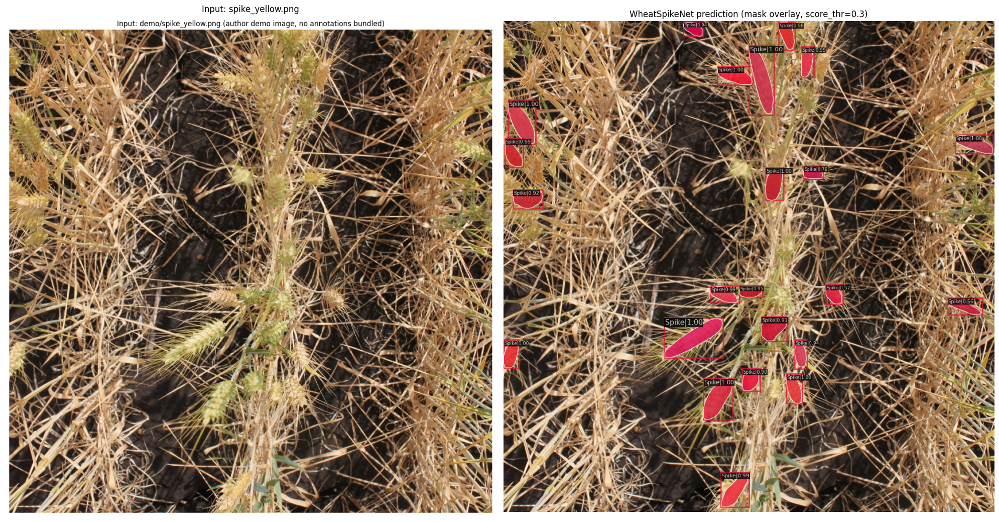

In [ ]:
import matplotlib.pyplot as plt, PIL.Image
inp = PIL.Image.open("/content/input_preview.png")
out = PIL.Image.open("/content/wsnet_prediction.png")
fig, axes = plt.subplots(1, 2, figsize=(20, 11), dpi=100)
axes[0].imshow(inp); axes[0].set_title("Input: spike_yellow.png"); axes[0].axis("off")
axes[1].imshow(out); axes[1].set_title("WheatSpikeNet prediction (mask overlay, score_thr=0.3)"); axes[1].axis("off")
plt.tight_layout(); plt.savefig("/content/input_vs_prediction.png", bbox_inches="tight"); plt.show() 

## 10. Small results table and CSV export

A compact record of the executed run: model input size, detected instance count, and confidence statistics of the kept detections (from the same `result` structure `image_demo.py` produces). Exported to CSV inside Colab.

**日本語:** 実行結果の要約（検出数・スコア統計）を表と CSV で保存します。

In [ ]:
%%bash
cat > /content/summarize.py <<'PY'
import matplotlib
matplotlib.use("Agg")  # headless Colab VM
import csv
from mmdet.apis import init_detector, inference_detector
import numpy as np
config = "/content/pheno-wheat/configs/models/WheatSpikeNet.py"
checkpoint = "/content/checkpoints/WheatSpikeNet.pth"
model = init_detector(config, checkpoint, device="cuda:0")
result = inference_detector(model, "/content/spike_yellow.png")
# mmdet 2.x result: [(per-class bbox arrays (N,5), per-class mask lists)]; 1 class: "Spike"
bboxes = result[0][0]
n = int(bboxes.shape[0])
scores = bboxes[:, 4] if n else np.array([])
from PIL import Image
w, h = Image.open("/content/spike_yellow.png").size
rows = [
    ("image", "demo/spike_yellow.png (git blob 9f579327)"),
    ("input_size_px", f"{w}x{h}"),
    ("checkpoint", "WheatSpikeNet.pth (figshare 39796816, md5 745c1cbe)"),
    ("detected_spikes", n),
    ("score_min", round(float(scores.min()), 4)),
    ("score_median", round(float(np.median(scores)), 4)),
    ("score_max", round(float(scores.max()), 4)),
    ("note", "single-image demo; not a dataset-level evaluation"),
]
with open("/content/wsnet_results.csv", "w", newline="") as f:
    csv.writer(f).writerows(rows)
for k, v in rows: print(f"{k}: {v}")
PY
MPLBACKEND=Agg /content/miniforge/envs/wheat/bin/python /content/summarize.py 

load checkpoint from local path: /content/checkpoints/WheatSpikeNet.pth
image: demo/spike_yellow.png (git blob 9f579327)
input_size_px: 1024x1024
checkpoint: WheatSpikeNet.pth (figshare 39796816, md5 745c1cbe)
detected_spikes: 23
score_min: 0.5627
score_median: 0.9909
score_max: 0.9996
note: single-image demo; not a dataset-level evaluation


/content/miniforge/envs/wheat/lib/python3.10/site-packages/mmcv/__init__.py:20: UserWarning: On January 1, 2023, MMCV will release v2.0.0, in which it will remove components related to the training process and add a data transformation module. In addition, it will rename the package names mmcv to mmcv-lite and mmcv-full to mmcv. See https://github.com/open-mmlab/mmcv/blob/master/docs/en/compatibility.md for more details.
  warnings.warn(
2026-10-05 02:21:48,745 - root - INFO - DeformConv2dPack backbone.layer2.0.conv2 is upgraded to version 2.
2026-10-05 02:21:48,747 - root - INFO - DeformConv2dPack backbone.layer2.1.conv2 is upgraded to version 2.
2026-10-05 02:21:48,748 - root - INFO - DeformConv2dPack backbone.layer2.2.conv2 is upgraded to version 2.
2026-10-05 02:21:48,749 - root - INFO - DeformConv2dPack backbone.layer2.3.conv2 is upgraded to version 2.
2026-10-05 02:21:48,750 - root - INFO - DeformConv2dPack backbone.layer3.0.conv2 is upgraded to version 2.
2026-10-05 02:21:48,753

## 11. Interpretation and limitations

- **What was executed:** the authors' released WheatSpikeNet (Cascade Mask R-CNN variant with DCN, FPN+BFP, SABL heads) on their bundled demo image, using their `image_demo.py` inference calls under the pinned stack (torch 1.13.1+cu117, mmcv-full 1.6.1, mmdetection v2.28.0) in a Python 3.10 env on a Colab T4.
- **What this does not verify:** the paper's dataset-level results (bbox AP 0.9303 / mask AP 0.9416 at IoU 0.5 on the SPIKE-segm test split; counting accuracy ≈86%, F1 0.93). Those require the SPIKE-segm test split with COCO annotations (Figshare 22347037) and the paper's counting protocol — out of scope for this single-image demo.
- **Known limitations** (from the paper): leaves misidentified as spikes; missed partially visible or heavily occluded spikes; annotation errors also penalize measured accuracy.
- **日本語:** 本ノートブックは著者提供のチェックポイントとデモ画像 1 枚による実行デモであり、論文のデータセット全体の AP・計数精度の検証ではありません。論文が挙げる限界（葉の誤検出、隠れ穂の見逃し等）はこのデモでも起こり得ます。

### References
- Batin et al., *Front. Plant Sci.* 14:1226190 (2023). https://doi.org/10.3389/fpls.2023.1226190
- Code: https://github.com/MABatin/pheno-wheat @ `a6c0caf746a8fcb29284111031a3c7658b14027e`
- Checkpoints: https://figshare.com/articles/journal_contribution/Trained_models/22359991 (CC BY 4.0)